In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np 
import xarray as xr
from pathlib import Path 
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import sys
import warnings 
import json, ast

DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
folders = [DIR+"/modules/", DIR+ "/dataset/", DIR+"/benchmarking/"]
for path in folders:
    if path not in sys.path:
        sys.path.append(path)
from helpers import *

In [3]:
RESULTS_DIR = "../v2.0/results_156_measurements/"

In [4]:
def get_immediate_subdirs(path):
    return [str(p) for p in Path(path).iterdir() if p.is_dir()]
def get_sorted_nc_files(path):
    files = [p for p in Path(path).iterdir() if p.is_file() and p.suffix == ".nc"]
    # sort by the integer after 'ds_' and before '.nc'
    files.sort(key=lambda p: int(p.stem.split("_")[1]))
    return [str(f) for f in files]

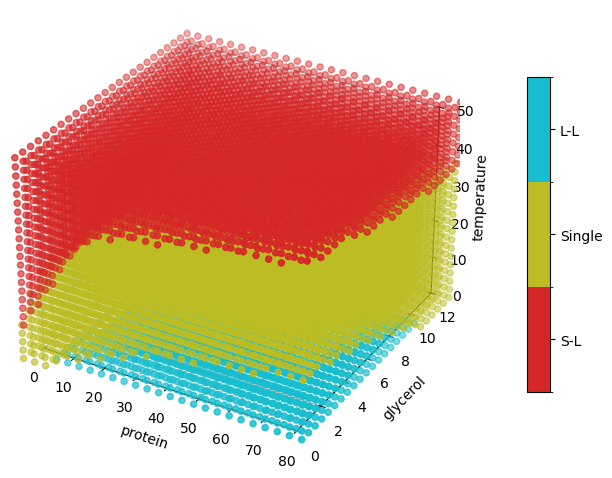

In [5]:
boundary_dataset = xr.load_dataset(DIR+'/dataset/250610-extrap_expand_dataset.nc')
ax = plot_phase_diagram(
    boundary_dataset, 
    "composition",
    "component",
    "labels"
    )
plt.tight_layout()

In [6]:
from evaluate import get_baseline_geodesics 

baseline_dists = get_baseline_geodesics(3) 
sums = {}
counts = {}
for d in baseline_dists:
    for k, v in d.items():
        sums[k] = sums.get(k, 0) + v
        counts[k] = counts.get(k, 0) + 1

# Compute averages
averages = {k: sums[k] / counts[k] for k in sums}

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[Iter     1] loss: 26.433647
[Iter     2] loss: 26.278849
[Iter     3] loss: 26.190710
[Iter     4] loss: 25.771408
[Iter     5] loss: 25.775200
Finished training in 6.04076s
[Iter     1] loss: 50.297577
[Iter     2] loss: 50.297577
Finished training in 3.06742s
[Iter     1] loss: 26.200527
[Iter     2] loss: 26.200527
Finished training in 2.64764s
[Iter     1] loss: 48.060715
[Iter     2] loss: 47.588364
[Iter     3] loss: 47.588364
Finished training in 3.05316s
[Iter     1] loss: 30.929979
[Iter     2] loss: 29.565832
[Iter     3] loss: 29.324104
[Iter     4] loss: 27.933697
[Iter     5] loss: 27.917603
Finished training in 12.23229s
[Iter     1] loss: 54.598961
[Iter     2] loss: 54.598961
Finished training in 2.65065s


In [7]:
def plot_geodesic_progress(ds, file, baselines):
    # --- Load data ---
    records = []
    with open(file, "r") as f:
        for line in f:
            line = line.strip()
            if line:  # skip empty lines
                records.append(json.loads(line))

    # --- Extract phase boundary keys dynamically ---
    keys = sorted(list(records[0].keys()))
    iterations = np.arange(len(records))
    measurements = np.asarray([(ds.batch_sample_id.values<=i).sum().item() for i in iterations])

    # Convert data into arrays with None -> np.nan
    data = {k: np.array([r.get(k, None) for r in records], dtype=float) for k in keys}

    # --- Valid mask for both curves existing ---
    valid_mask = np.isfinite(data[keys[0]]) & np.isfinite(data[keys[1]])

    # --- Compute derivatives over iterations ---
    deriv0 = np.diff(data[keys[0]], prepend=np.nan)
    deriv1 = np.diff(data[keys[1]], prepend=np.nan)

    # --- Convergence: derivatives small for the remainder of trajectory ---
    convergence_idx = None
    delta = 10.0
    for idx in range(len(valid_mask)-1):
        if valid_mask[idx]:
            # Check all remaining derivatives
            if np.all(np.abs(deriv0[idx:]) < delta) and np.all(np.abs(deriv1[idx:]) < delta):
                convergence_idx = idx
                break

    # --- First iteration where both exist till the end ---
    first_both_idx = None
    for idx in range(len(valid_mask)):
        if np.all(valid_mask[idx:]):
            first_both_idx = idx
            break

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(4*1.6, 4))

    color1 = "tab:blue"
    color2 = "tab:orange"

    # Plot first boundary (shifted by baseline)
    y = data[keys[0]] - baselines[ast.literal_eval(keys[0])]-5.0
    y = data[keys[0]] - 40.0
    ax.plot(measurements, 
             y/np.nanmax(y),
             color=color1, 
             label="Solubility"
        )
    ax.set_xlabel("Number of Measurements")
    ax.set_ylabel(f"Normalized Boundary Score")

    y = data[keys[1]] - baselines[ast.literal_eval(keys[1])]-5.0
    y = data[keys[1]] - 15.0
    ax.plot(measurements, 
             y/np.nanmax(y),
             color=color2, 
             label="Liquid-Liquid"
        )

    # Vertical line: first iteration where both boundaries are observed till end
    if first_both_idx is not None:
        ax.axvline(measurements[first_both_idx], color="grey", linestyle="--", lw=1.5)
        ax.text(measurements[first_both_idx] + 0.5, ax.get_ylim()[1]*0.9,
                 f"Both observed after {measurements[first_both_idx]} measurements",
                 rotation=0, va="top", color="grey")

    # Vertical line: convergence
    # if convergence_idx is not None:
    #     ax1.axvline(convergence_idx, color="red", linestyle="--", lw=1.5)
    #     ax1.text(convergence_idx + 0.5, ax1.get_ylim()[1]*0.8,
    #              f"Convergence @ {convergence_idx}",
    #              rotation=90, va="top", color="red")

    # Baseline lines
    ax.axhline(0.0, color="k", linestyle="--", lw=1.5)
    ax.legend()

    plt.title("Phase boundary scores over iterations")
    fig.tight_layout()
    plt.show()


### P0: Standard phase mapping in 3D space

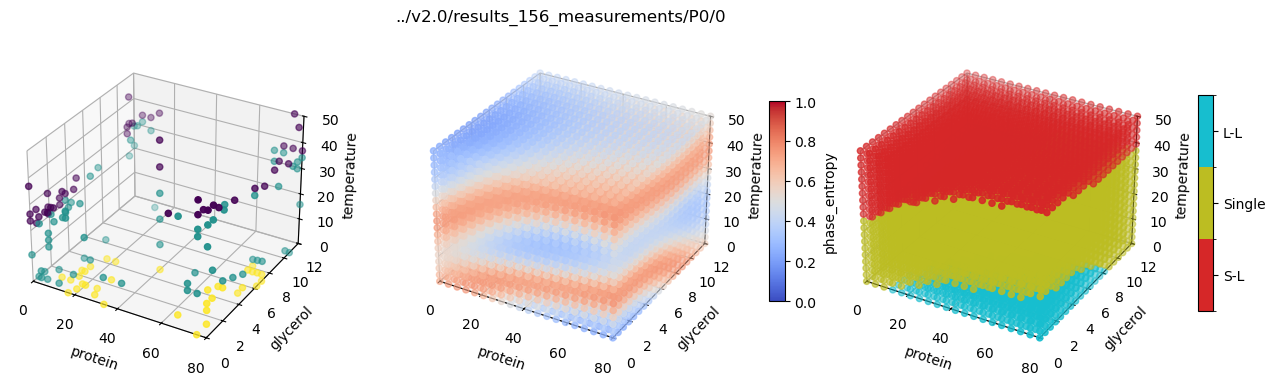

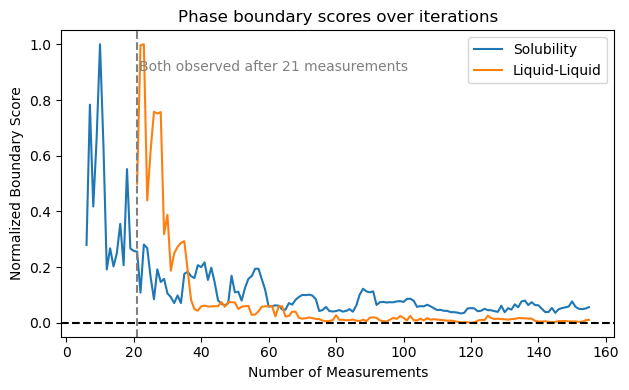

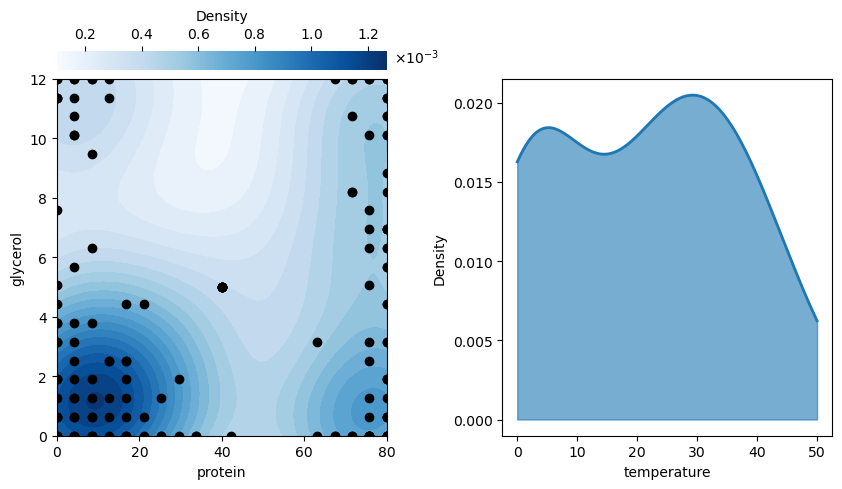

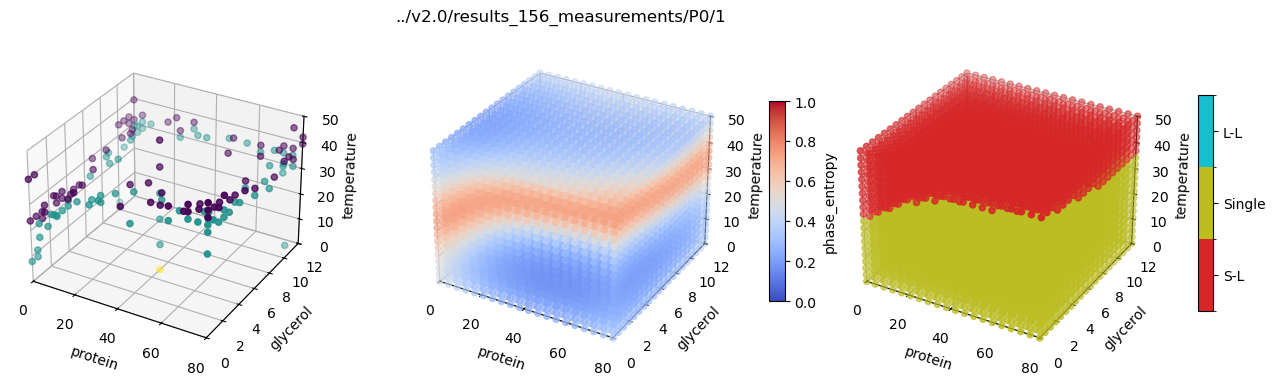

/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_34109/2589314710.py:62: RuntimeWarning: All-NaN slice encountered
  y/np.nanmax(y),


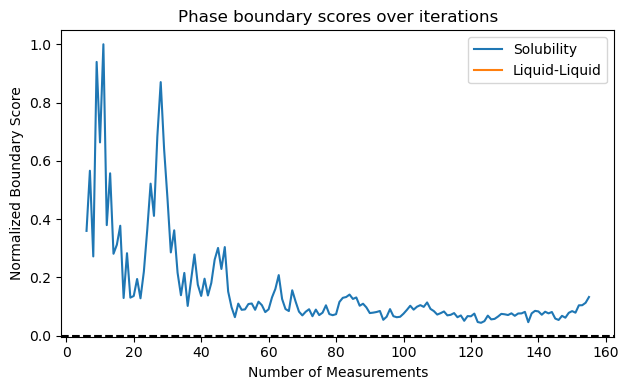

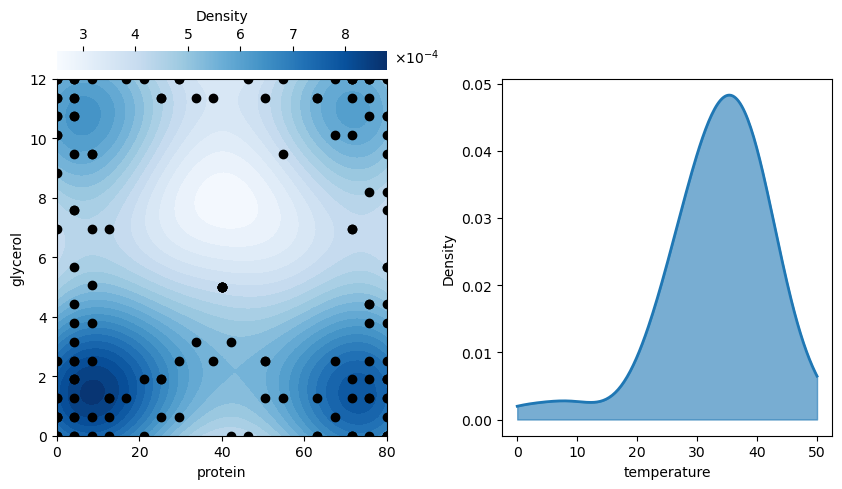

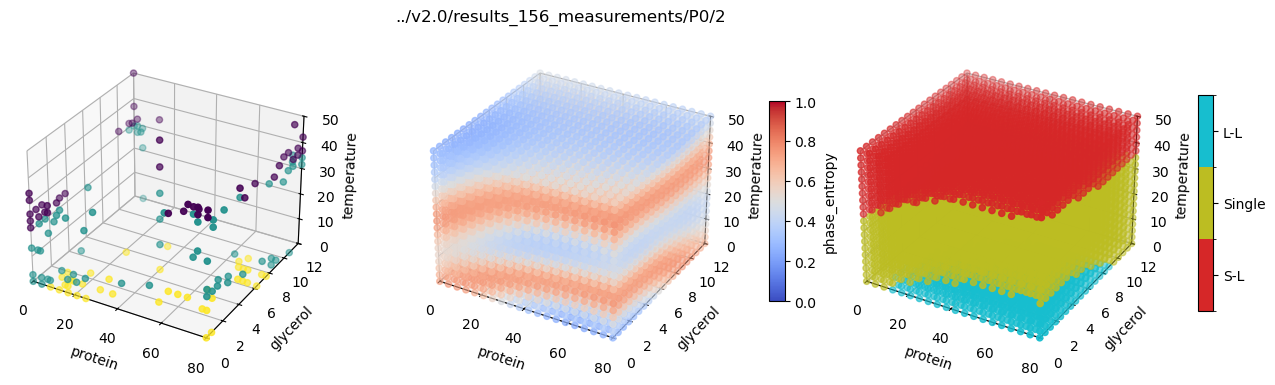

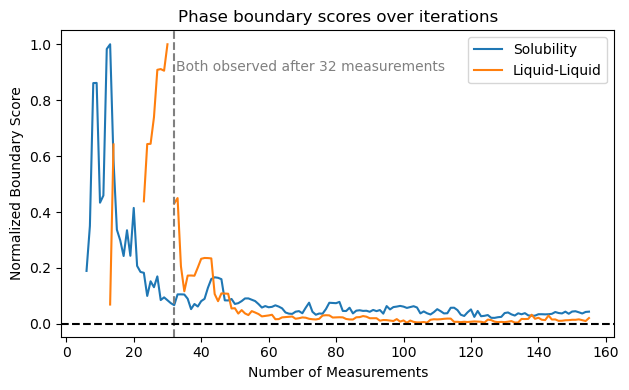

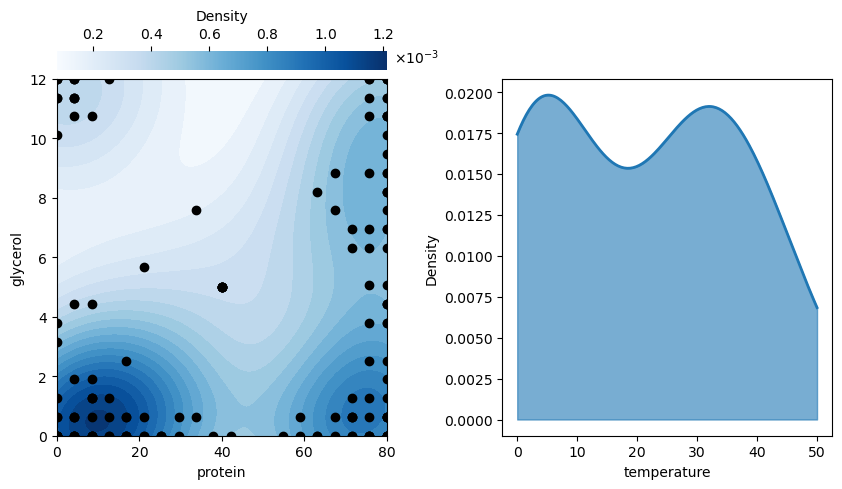

In [8]:
pipeline_direc = f"./{RESULTS_DIR}/P0/"
run_direcs = get_immediate_subdirs(pipeline_direc)
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_progress_p1(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
    )
    fig.suptitle(direc)
    plt.show()

    file = f"./{direc}/dists.json"
    plot_geodesic_progress(ds, file, averages)

    plot_sampling_densities(ds)

### P1 : Sample a composition and temperature combination from a 3D space

In [9]:
pipeline_direc = f"./{RESULTS_DIR}/P1/"
run_direcs = get_immediate_subdirs(pipeline_direc)
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_progress_p1(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
    )
    fig.suptitle(direc)
    plt.show()

    file = f"./{direc}/dists.json"
    plot_geodesic_progress(file, averages)

FileNotFoundError: [Errno 2] No such file or directory: '../v2.0/results_156_measurements/P1'

## P2 : Single composition and temperature with feasibility scaled acquisition

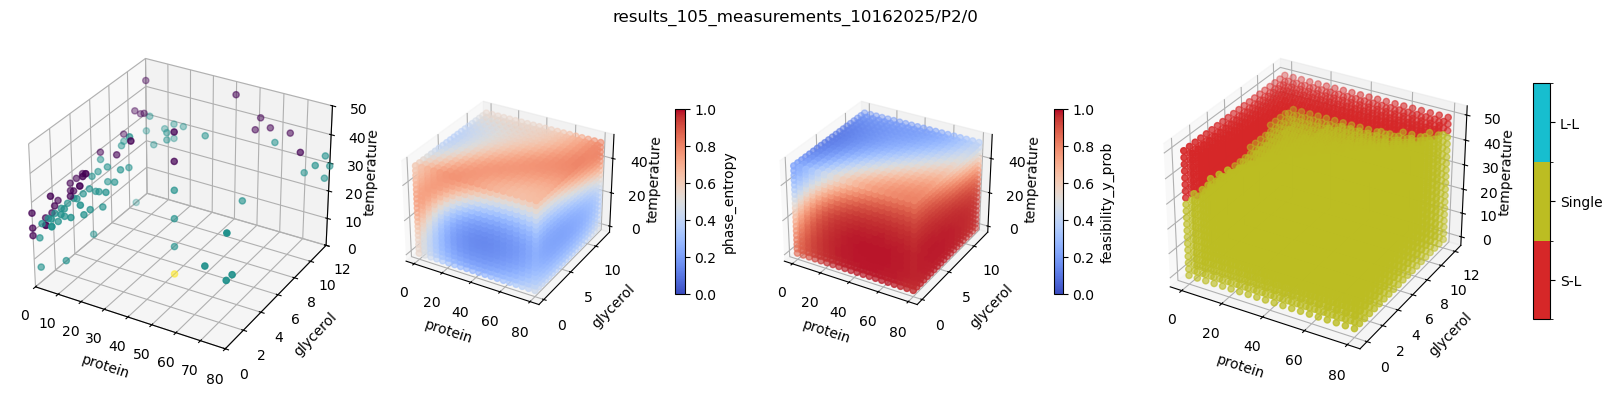

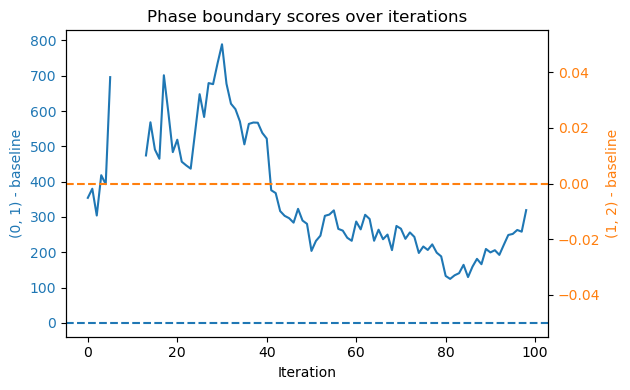

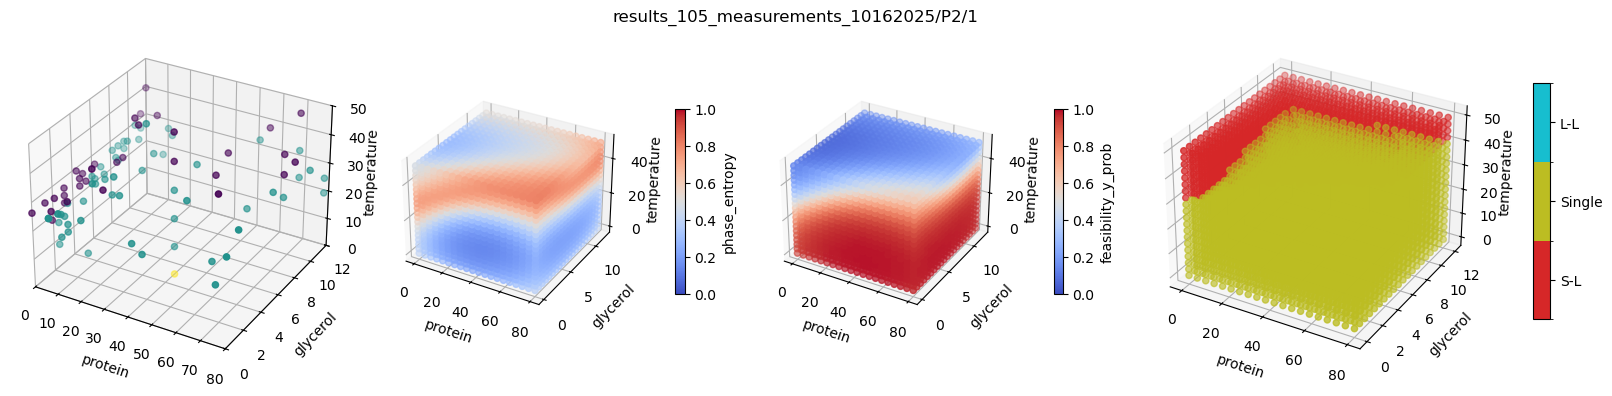

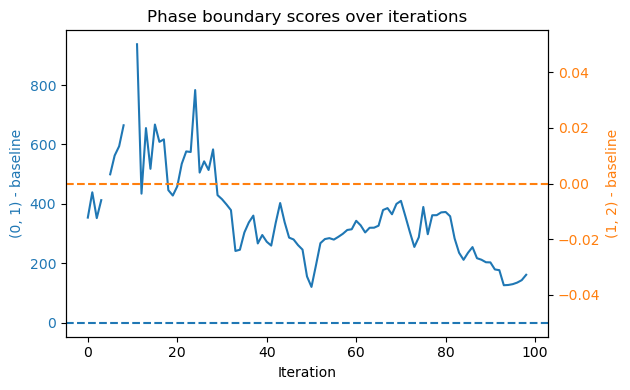

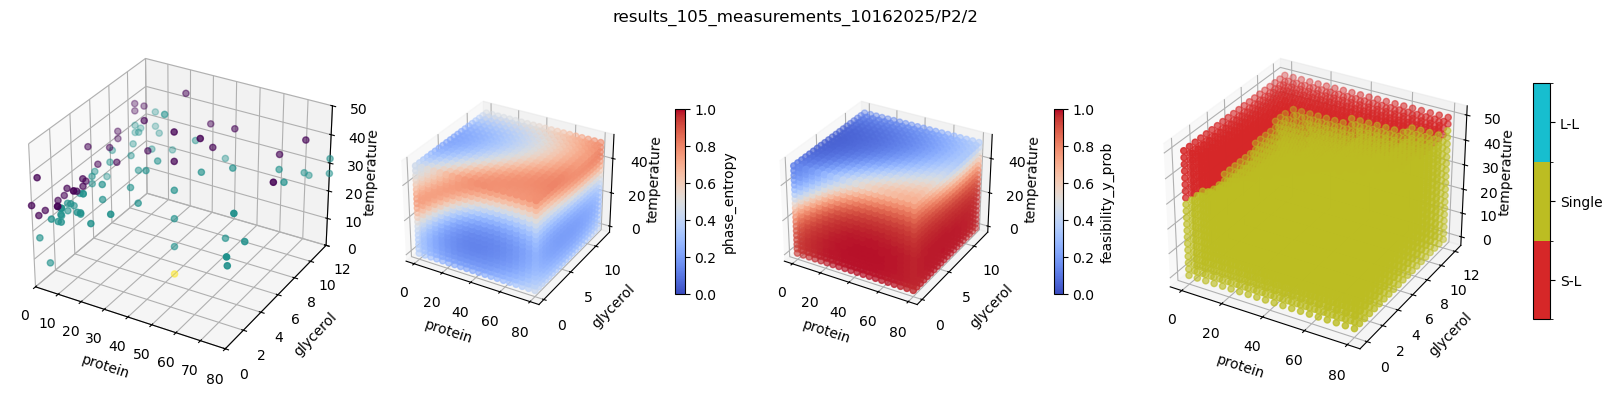

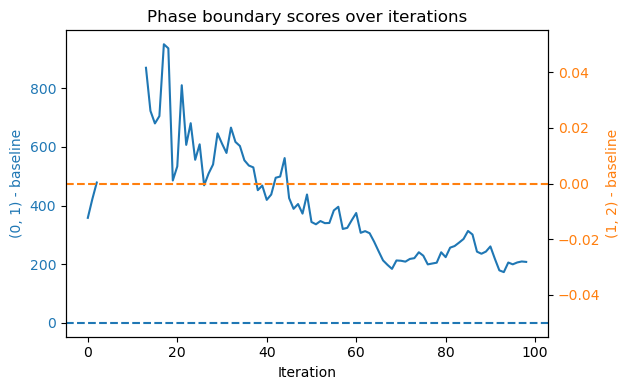

In [ ]:
pipeline_direc = f"./{RESULTS_DIR}/P2/"
run_direcs = get_immediate_subdirs(pipeline_direc)
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    fig.suptitle(direc)
    plt.show()
    file = f"./{direc}/dists.json"
    plot_geodesic_progress(file, averages)

## P3 : Single composition and batch temperature based on FWHM near phase boundaries

In [10]:
pipeline_direc = f"./{RESULTS_DIR}/P3/"
run_direcs = get_immediate_subdirs(pipeline_direc)

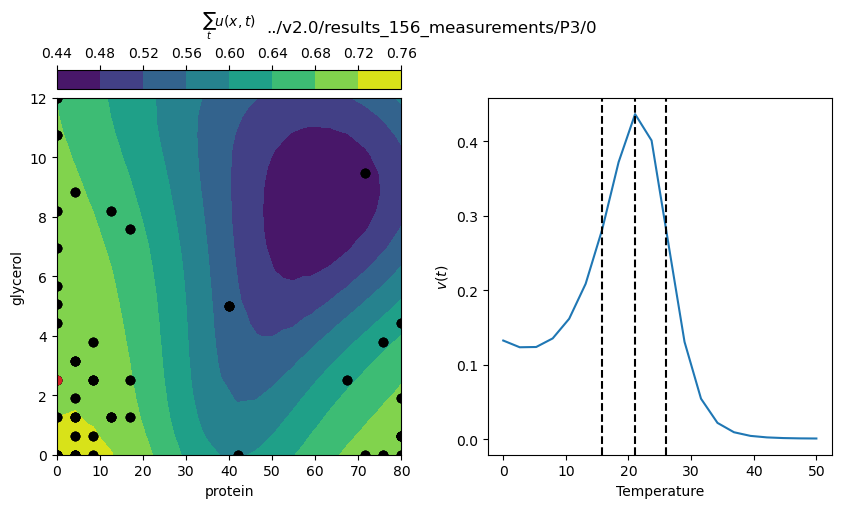

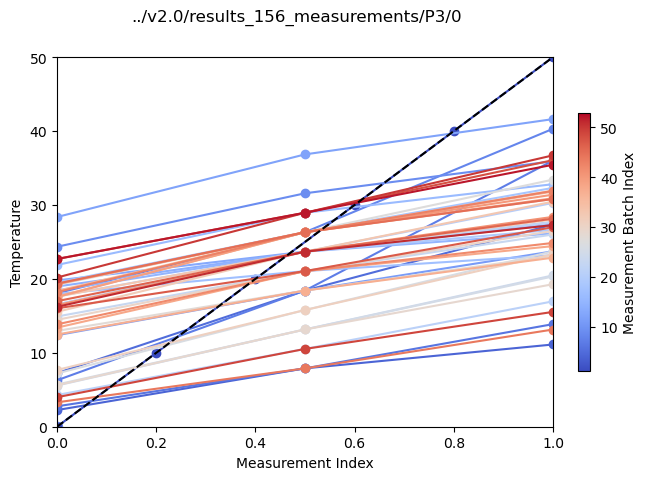

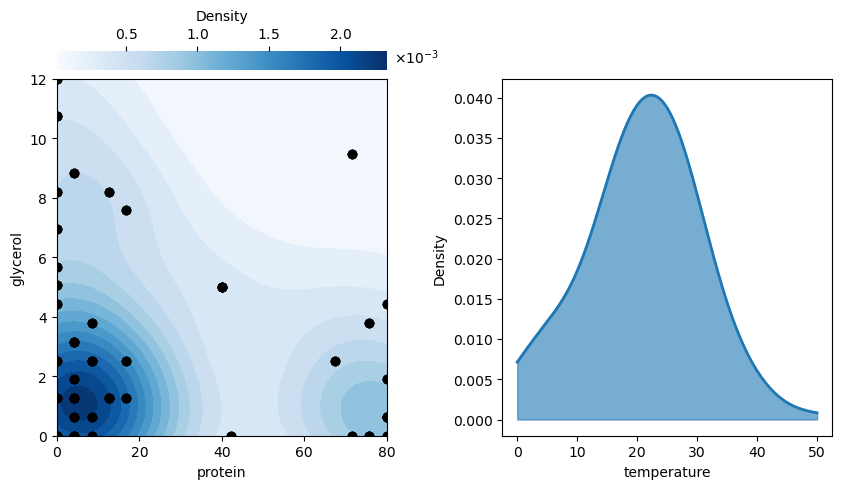

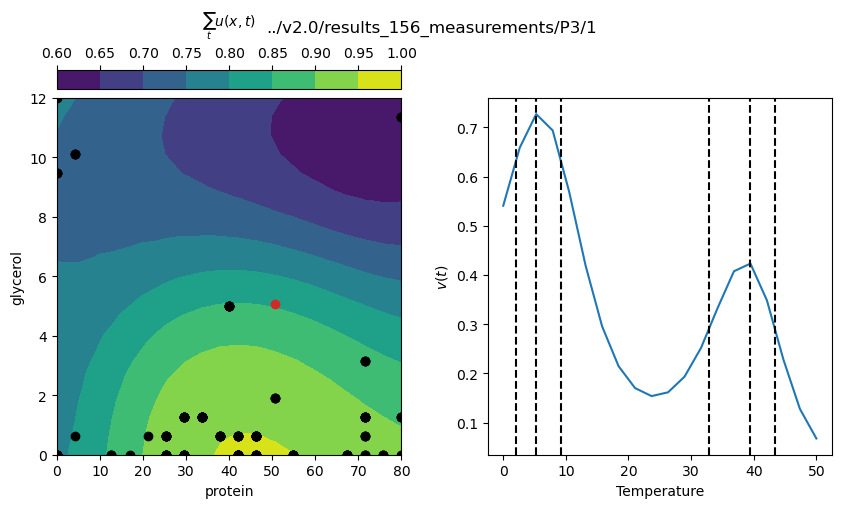

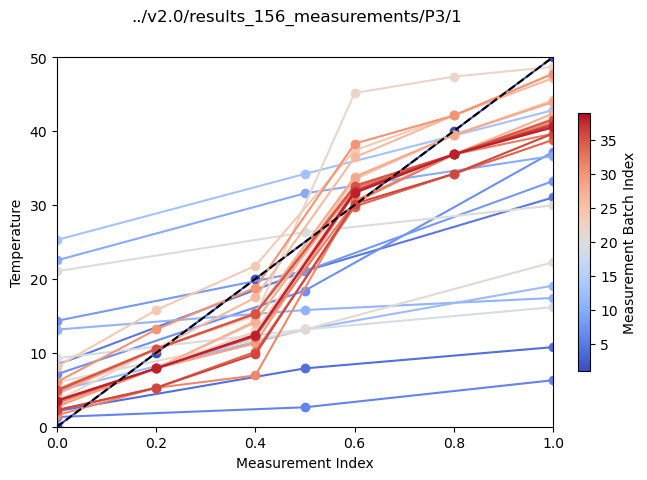

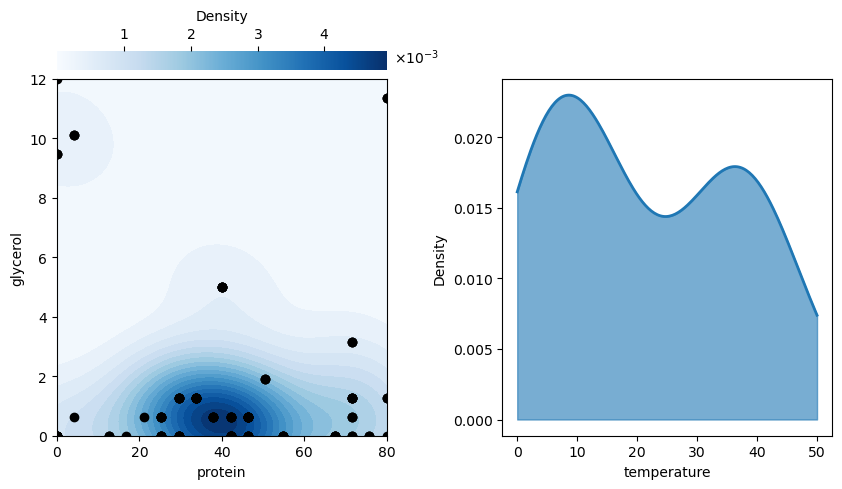

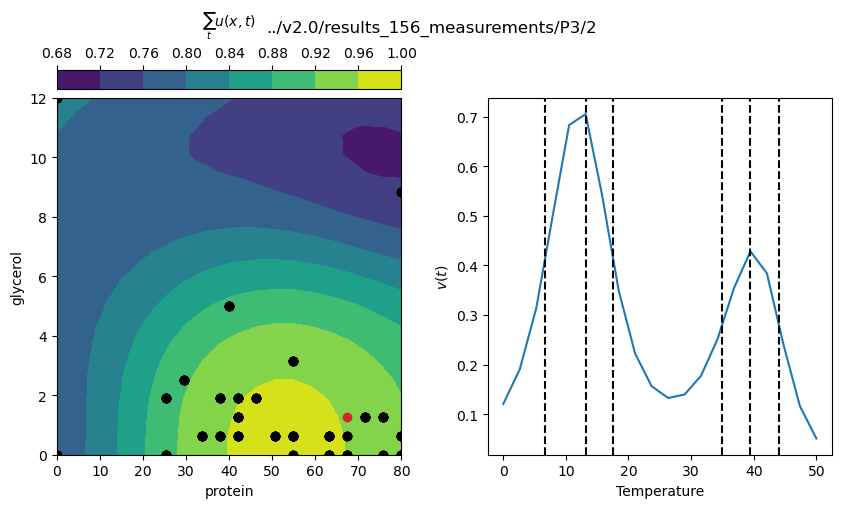

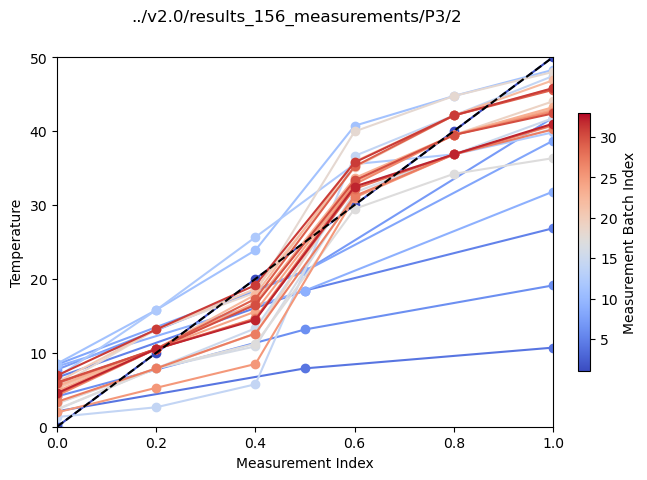

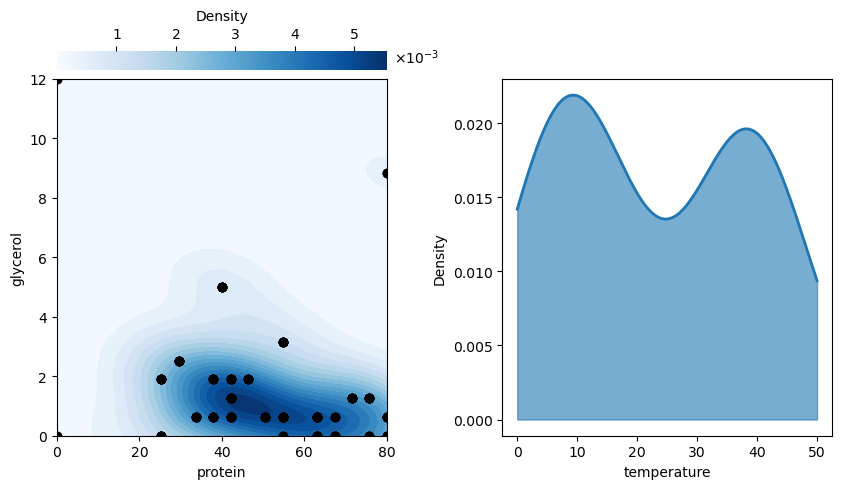

In [11]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility",
        "composition_next",
        "temperature_domain",
        "temperature_utility_with_cost",
        "temperature_next"
    )
    fig.suptitle(direc)
    plt.show()

    df, fig, ax , cbar = plot_temperature_profies(ds)
    fig.suptitle(direc)
    plt.show()

    plot_sampling_densities(ds)

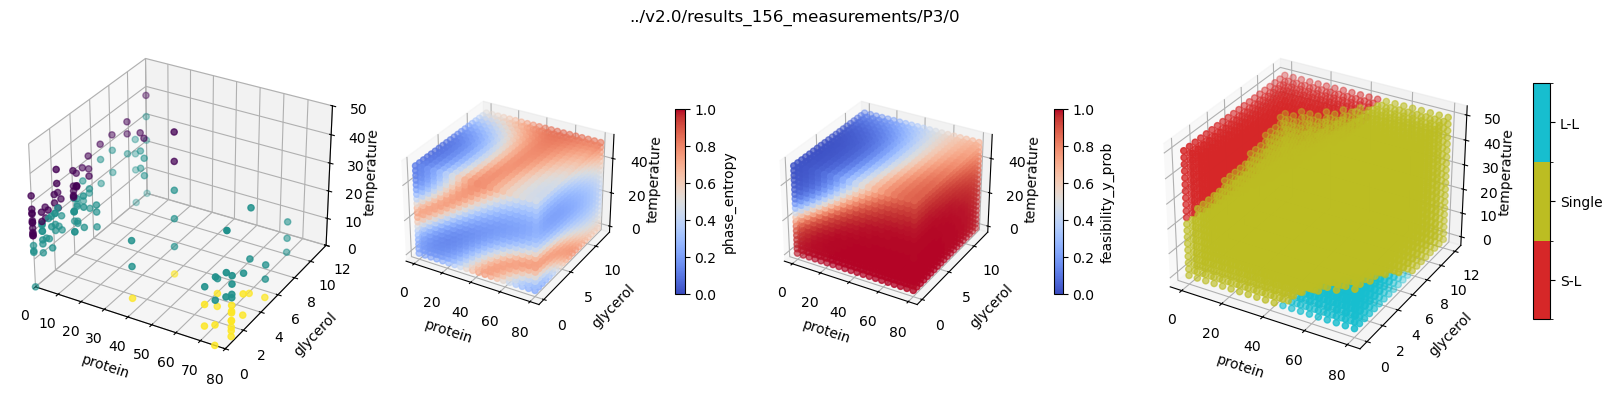

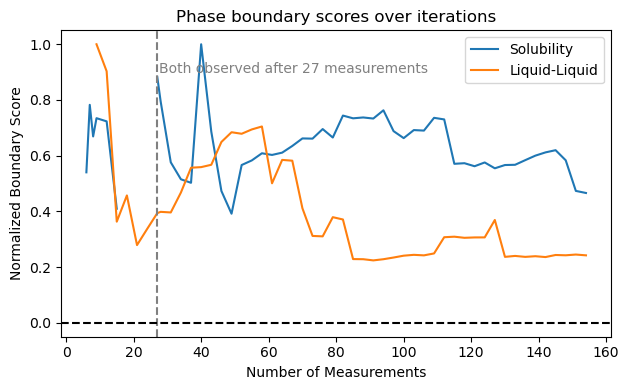

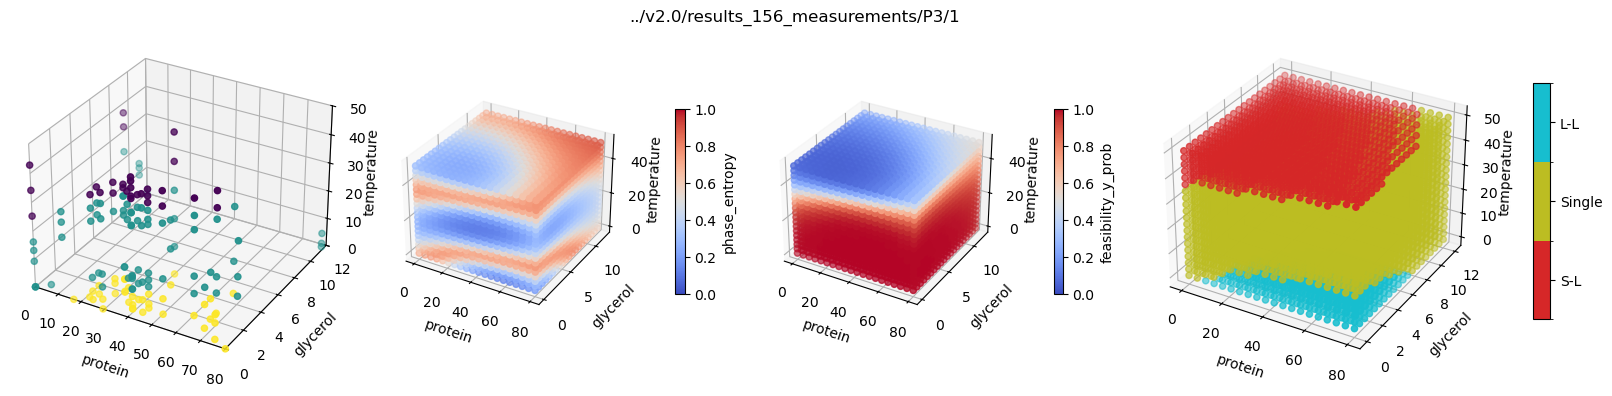

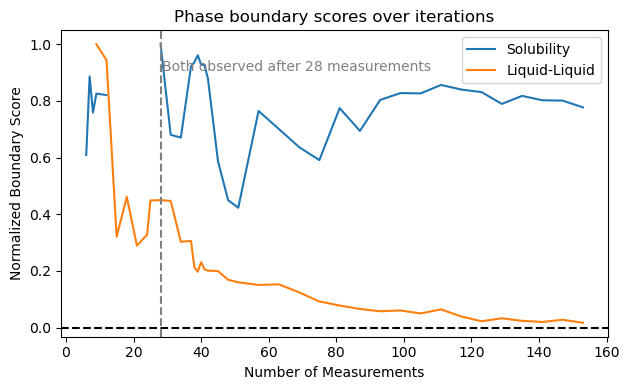

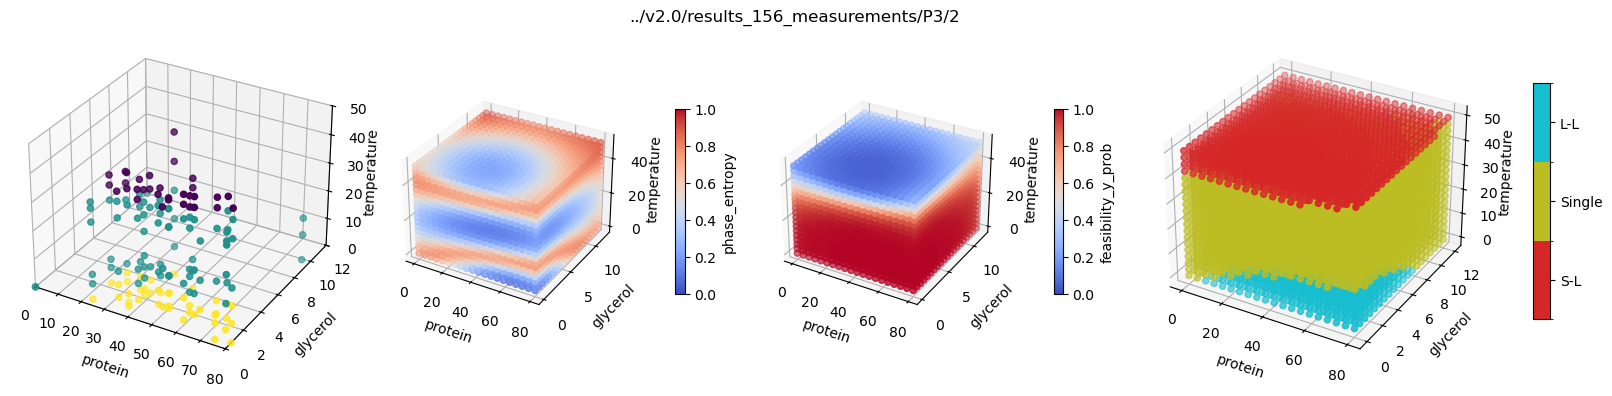

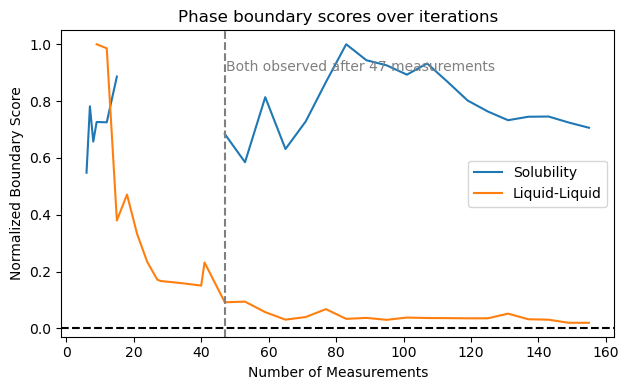

In [12]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    fig.suptitle(direc)
    plt.show()

    file = f"./{direc}/dists.json"
    plot_geodesic_progress(ds, file, averages)

## P4: Single composition with batch of times adaptively selected through acquisition optimization

In [ ]:
pipeline_direc = f"./{RESULTS_DIR}/P4/"
run_direcs = get_immediate_subdirs(pipeline_direc)

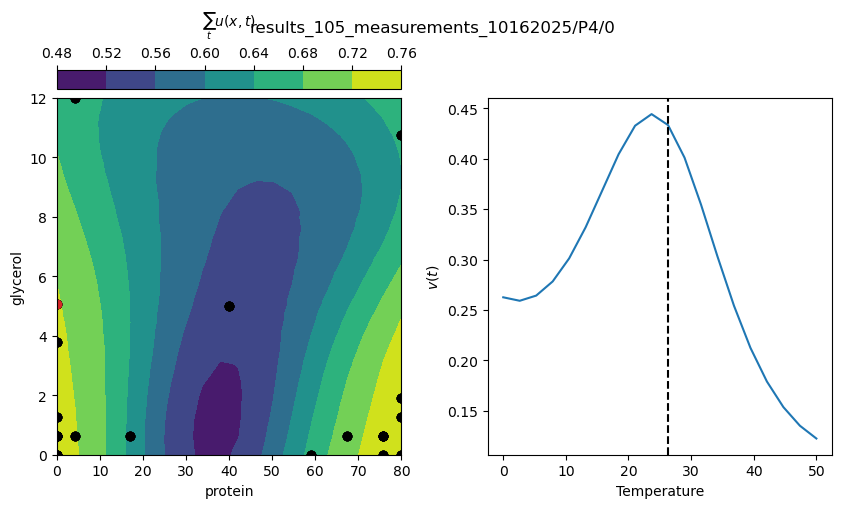

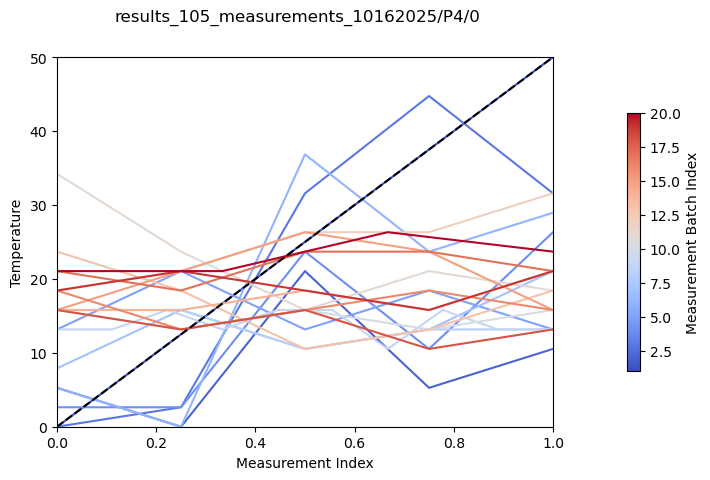

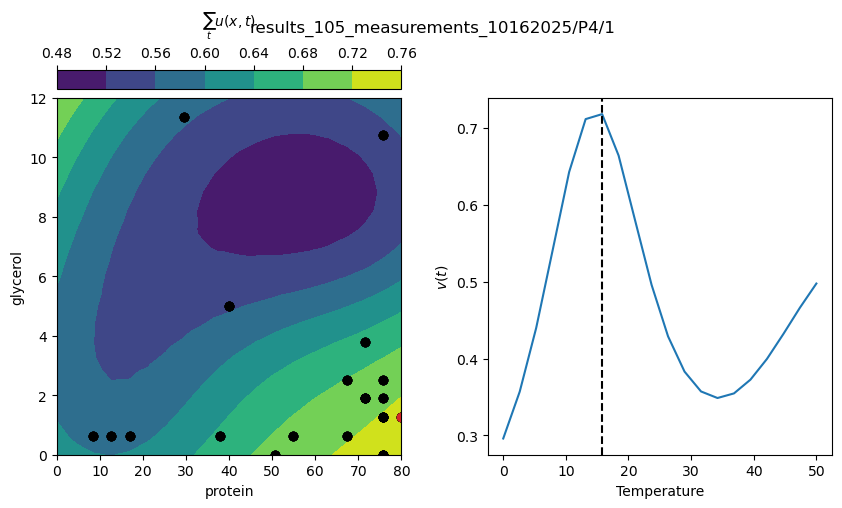

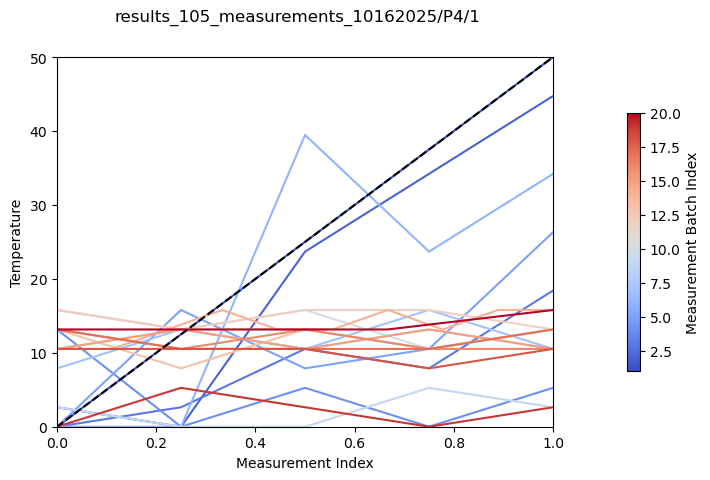

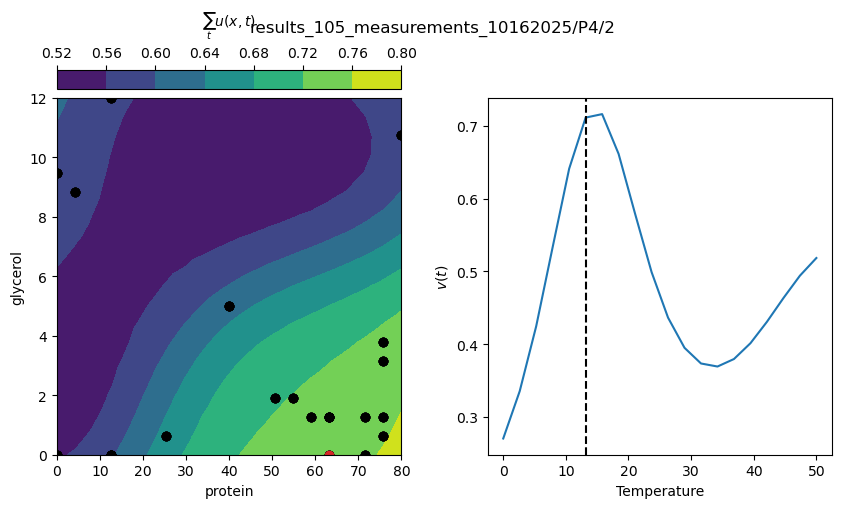

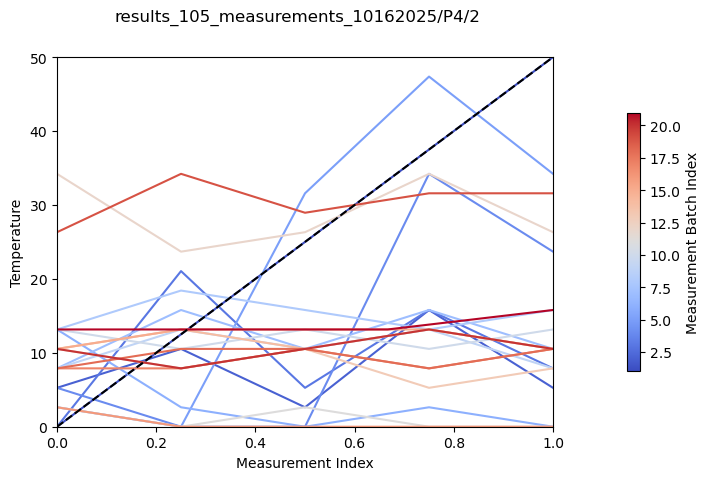

In [ ]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility",
        "composition_next",
        "temperature_domain",
        "temperature_utility_with_cost",
        "temperature_next"
    )
    fig.suptitle(direc)
    plt.show()

    df, fig, ax , cbar = plot_temperature_profies(ds)
    fig.suptitle(direc)
    plt.show()

The above plots shows that optimization of v(t) is still not resulting in different temperatures when v(t) doesn't change between updates.

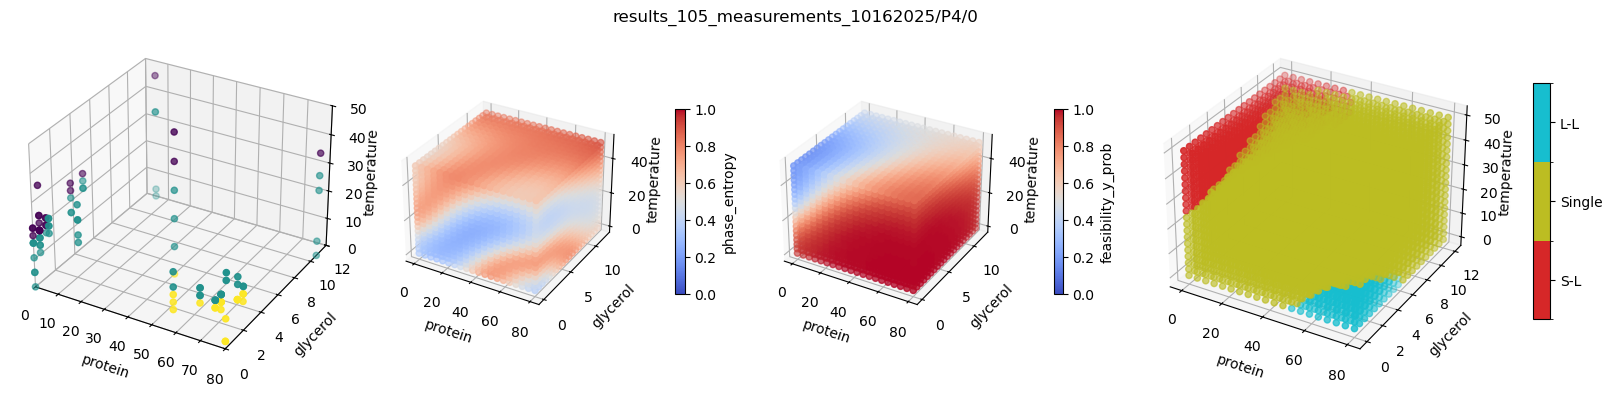

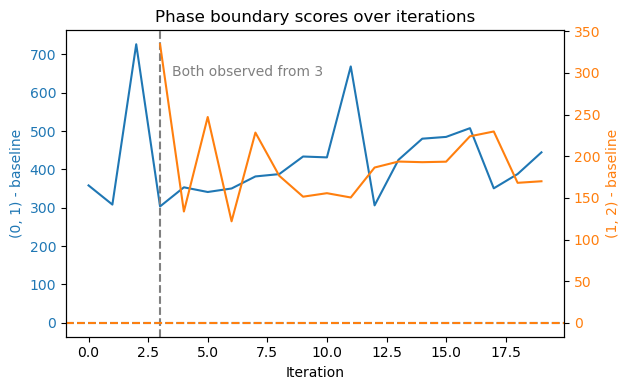

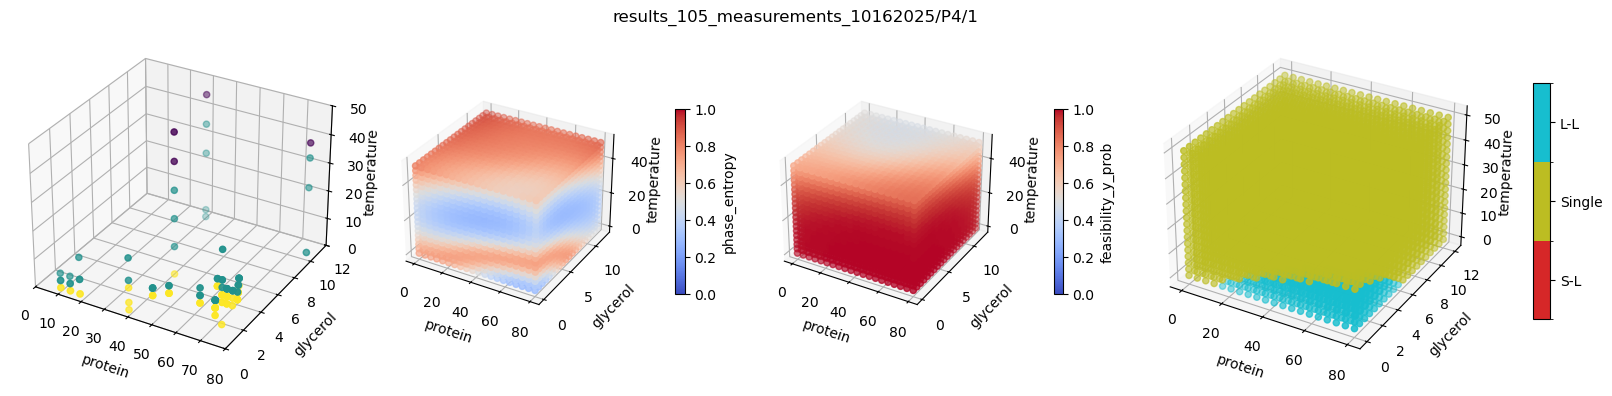

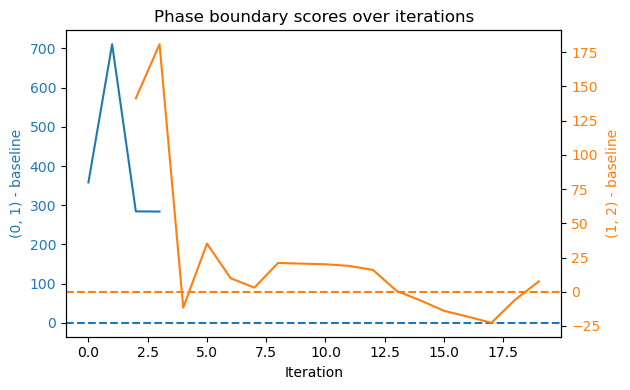

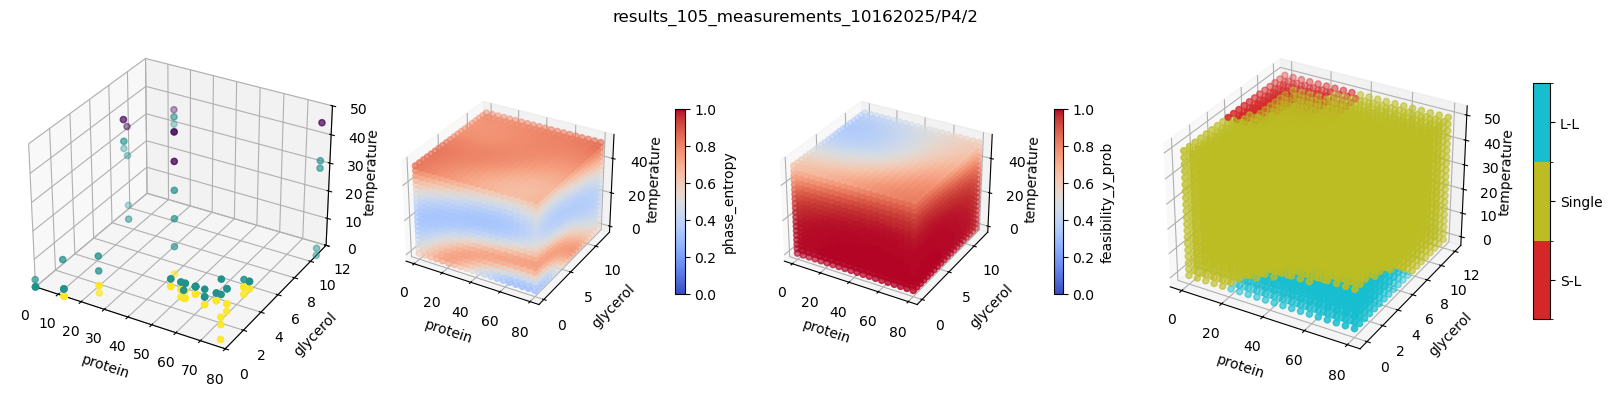

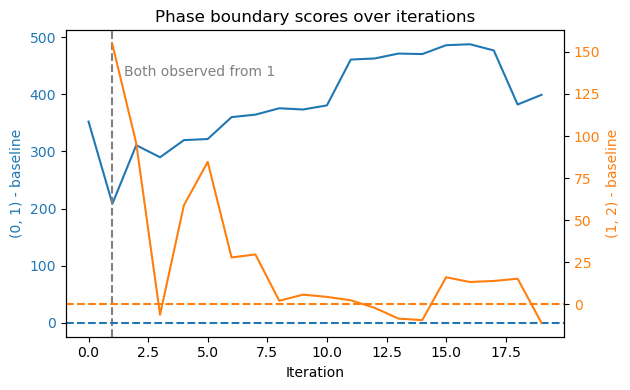

In [ ]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    fig.suptitle(direc)
    plt.show()

    file = f"./{direc}/dists.json"
    plot_geodesic_progress(file, averages)

## P5: Single composition with temperatures sampled linearly between the feasible region

In [ ]:
pipeline_direc = f"./{RESULTS_DIR}/P5/"
run_direcs = get_immediate_subdirs(pipeline_direc)

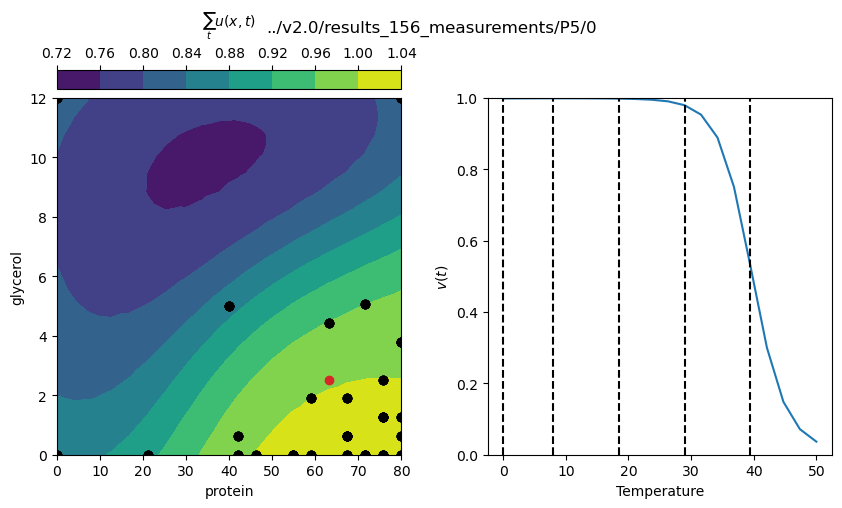

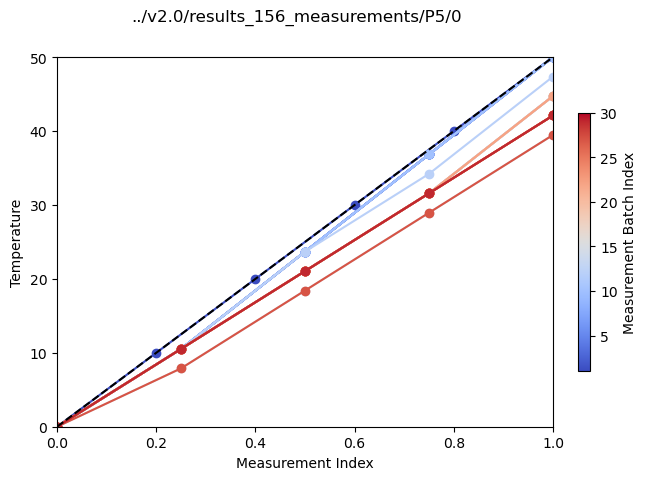

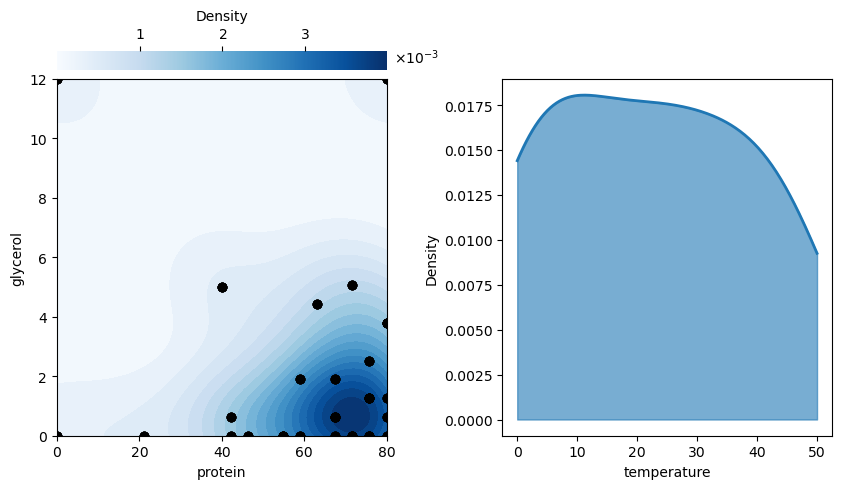

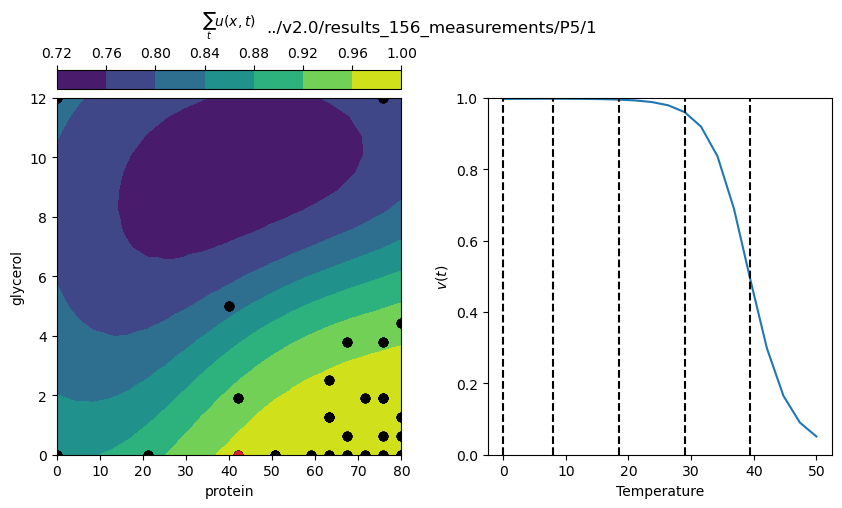

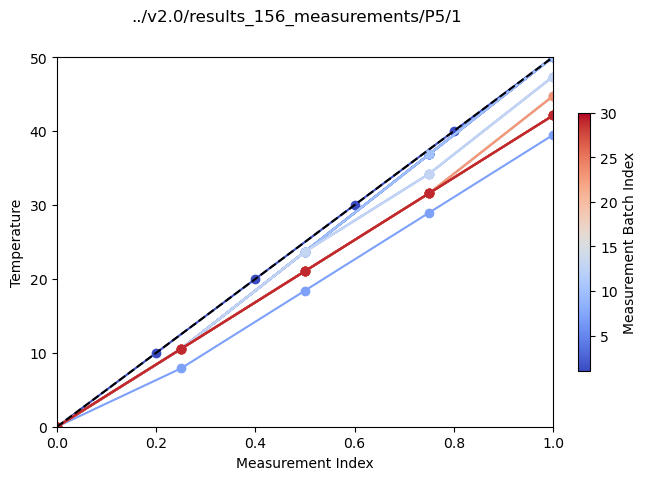

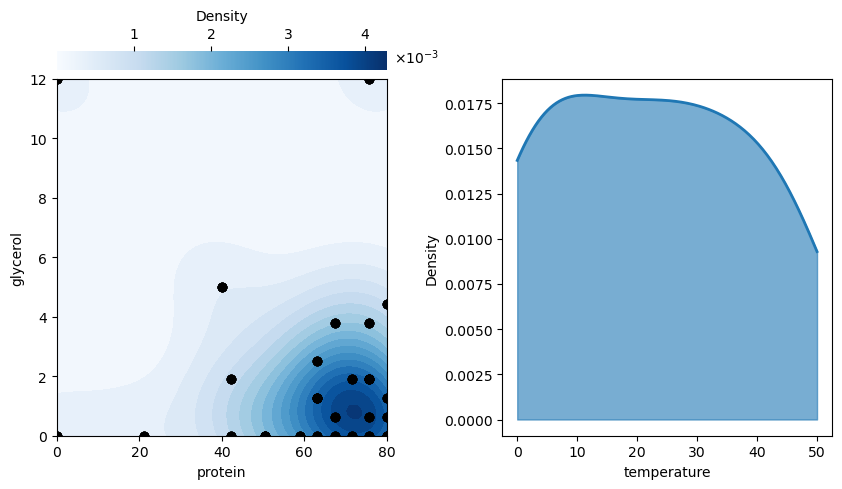

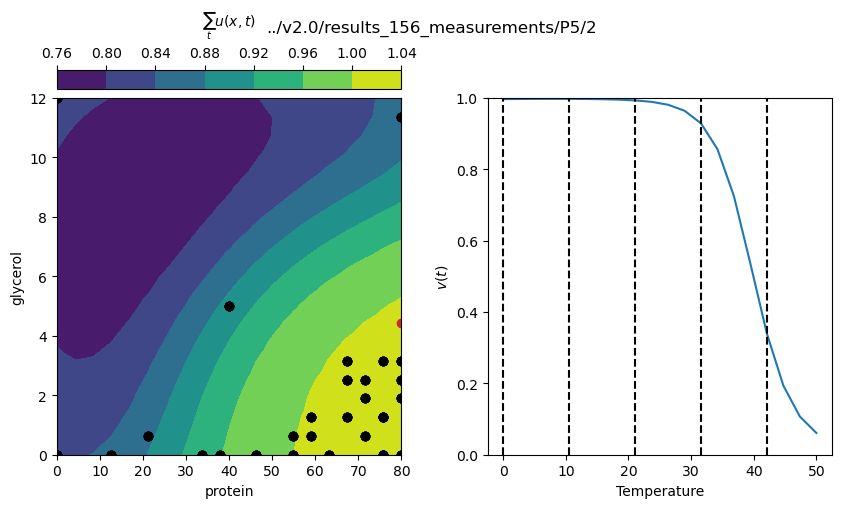

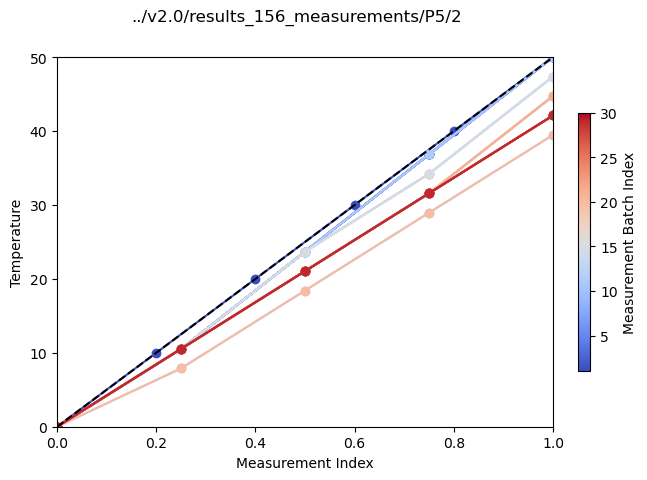

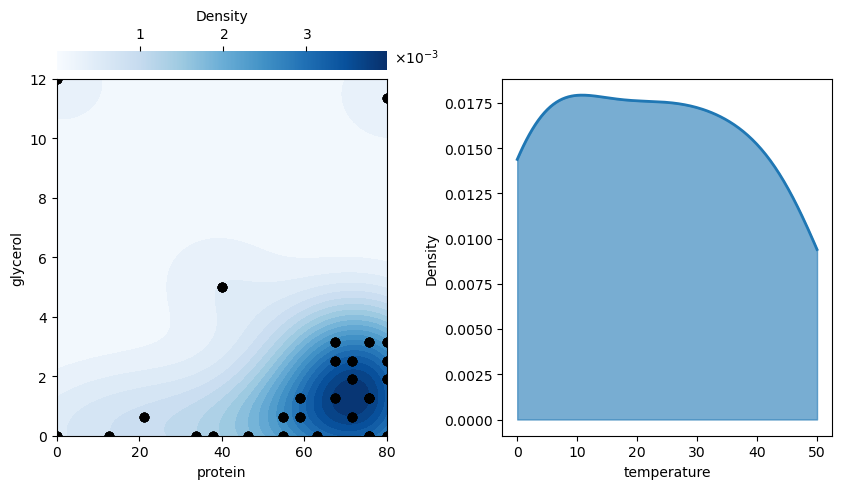

In [ ]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_sampling(
        ds,
        "design_space",
        "ds_dim",
        "protein_glycerol_domain",
        "composition_utility",
        "composition_next",
        "temperature_domain",
        "temperature_utility",
        "temperature_next"
    )
    axs[-1].set_ylim([0, 1])
    fig.suptitle(direc)
    plt.show()

    df, fig, ax , cbar = plot_temperature_profies(ds)
    fig.suptitle(direc)
    plt.show()

    plot_sampling_densities(ds)

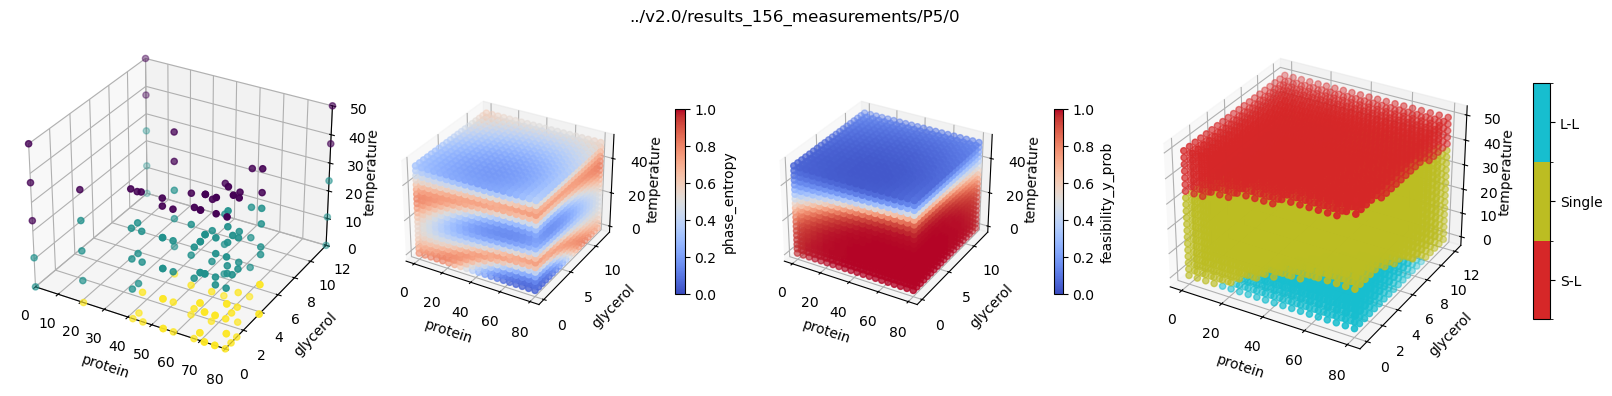

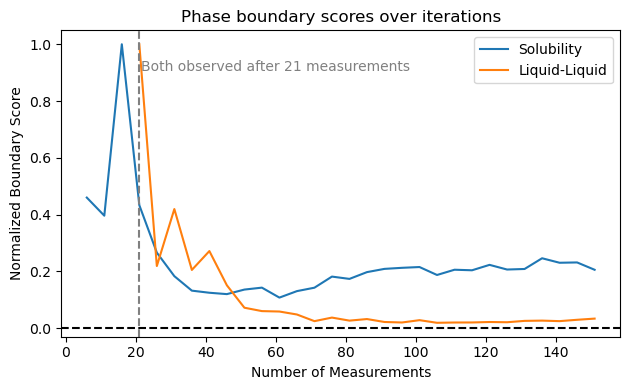

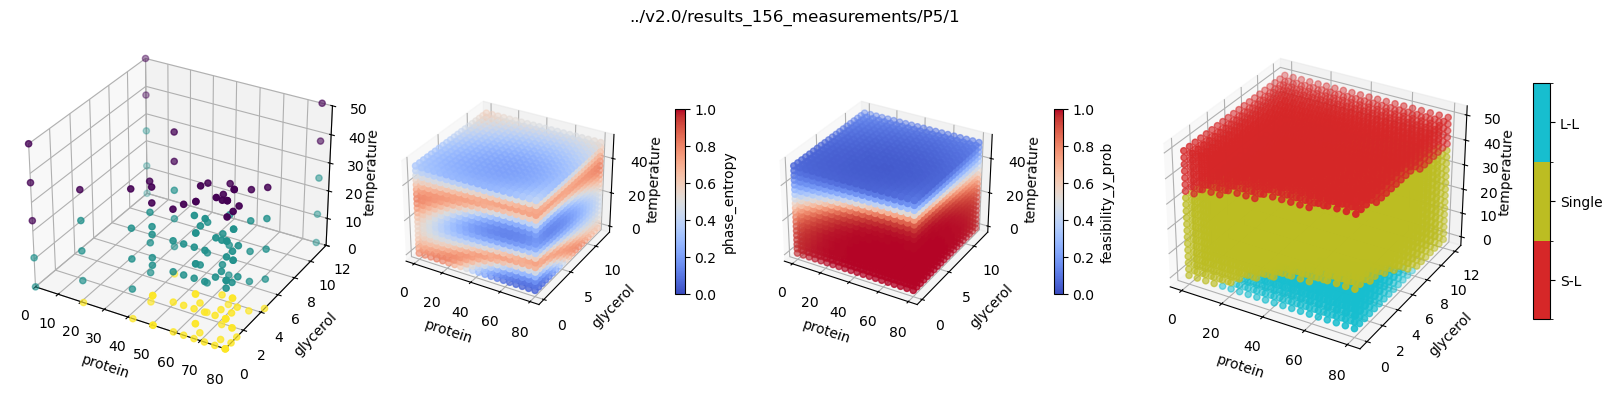

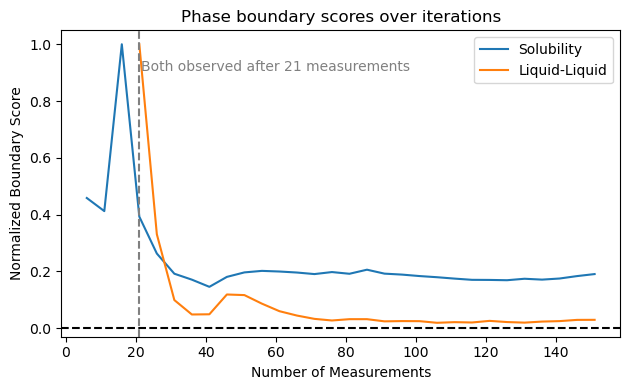

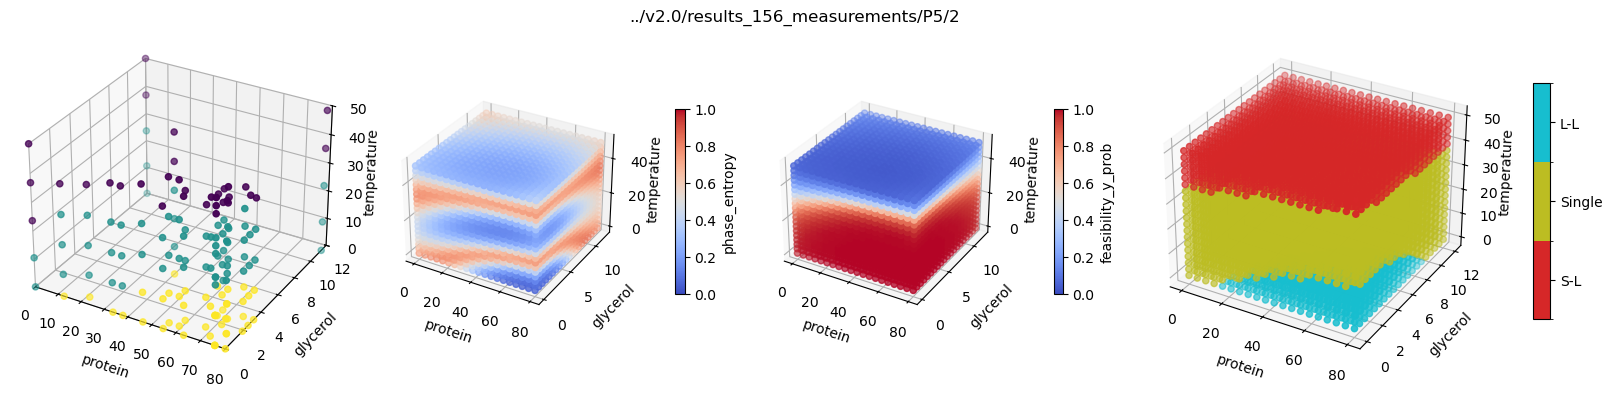

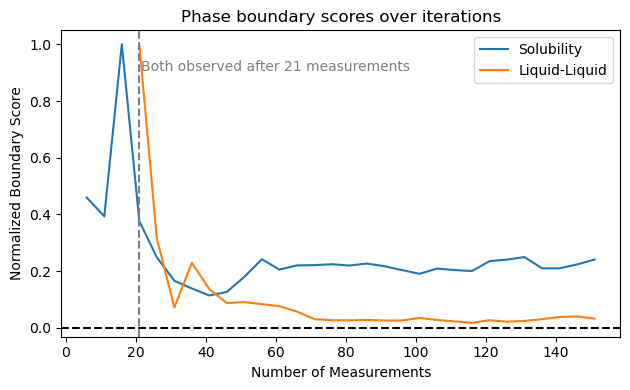

In [ ]:
for direc in run_direcs:
    ds_file = direc+"/ds.nc"
    ds = xr.load_dataset(ds_file)
    fig, axs = plot_progress(
        ds,
        design_space_variable="design_space", 
        grid_variable="design_space_grid", 
        design_space_dim="ds_dim", 
        composition_variables=["protein", "glycerol"],
        temperature_variable="temperature",
        labels_variable="phases",
        phase_probability_variable="phase_entropy",
        feasibilty_probability_variable="feasibility_y_prob"
    )
    fig.suptitle(direc)
    plt.show()

    file = f"./{direc}/dists.json"
    plot_geodesic_progress(ds, file, averages)

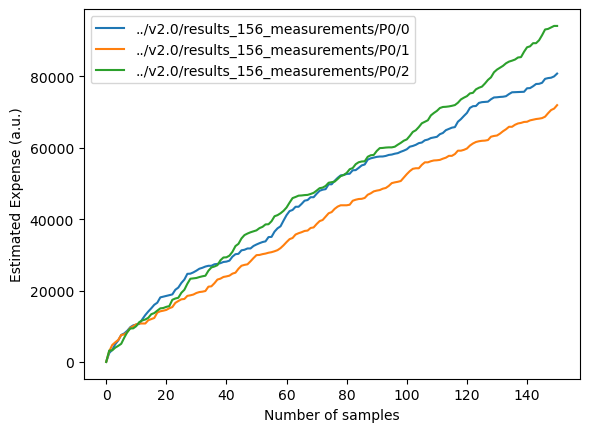

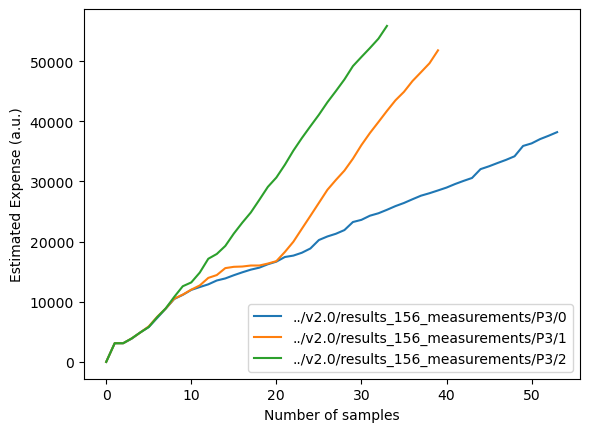

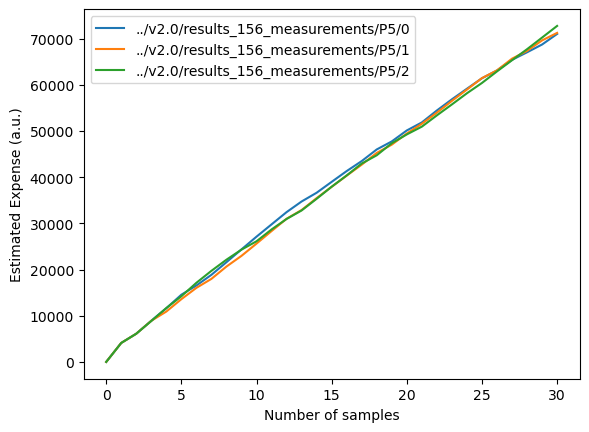

In [ ]:
pipeline_direcs = sorted(get_immediate_subdirs(RESULTS_DIR))

for pdirec in pipeline_direcs:
    fig, ax = plt.subplots()
    for j in range(3):
        direc = pdirec+f"/{j}"
        try:
            expense = np.load(direc+"/expense.npy")
            ax.plot(
                np.arange(expense.shape[0]), 
                expense,
                label = f"{direc}"
            )
        except FileNotFoundError:
            warnings.warn(f"No expense file found for {direc}, run may not have finished.")

    if "budget" in RESULTS_DIR:
        import re
        match = re.search(r"results_(.+?)_budget", RESULTS_DIR)
        sci_str = match.group(1)
        float_str = sci_str.replace('p', '.').replace('m', '-')
        ax.axhline(float(float_str), ls='--', color="k")
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Estimated Expense (a.u.)")
    ax.legend()
    plt.show()